#### Tissera Ana Paula - `Notebook TP3`

In [2]:
%load_ext autoreload
%autoreload 2

##### Imports

In [2]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import itertools
import cupy as cp # uso cupy en vez de numpy para correr en GPU que es más rápido

In [3]:
# Obtener el índice del dispositivo actual
device_id = cp.cuda.Device().id

# Obtener el nombre de la GPU actual
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [4]:
SEED = 42

### `1.` **Análisis y Preprocesamiento de Datos**

In [5]:
X_images = cp.load("data/X_images.npy")
y_images = cp.load("data/y_images.npy")


In [7]:
print("Forma de X:", X_images.shape)
print("Forma de y:", y_images.shape)
print("Etiquetas únicas:", cp.unique(y_images))


Forma de X: (5000, 784)
Forma de y: (5000,)
Etiquetas únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


### Visualización de imágenes

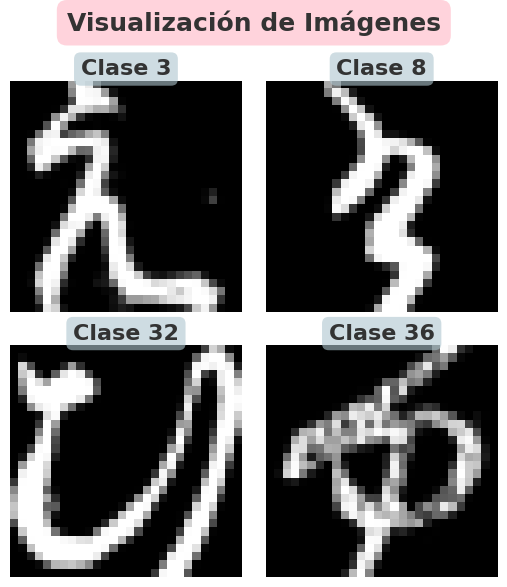

In [6]:
from src.plot import plot_images

# Mapa de nombres
name_map = {int(i): f"Clase {int(i)}" for i in cp.unique(y_images)}

# Selección aleatoria de índices por clase
cp.random.seed(44)
clases = cp.unique(y_images)
clases_seleccion = cp.random.choice(clases, size=4, replace=False)
indices = []
for cl in clases_seleccion:
    idxs_cl = cp.where(y_images == cl)[0]
    # pedimos tamaño 1 y extraemos el escalar
    idx = int(cp.random.choice(idxs_cl, size=1)[0])
    indices.append(idx)

# Visualización de imágenes
plot_images(
    X_images, y_images,
    indices=indices,
    n_cols=2,
    suptitle="Visualización de Imágenes",
    name_map=name_map,
    random_seed=SEED
)

In [7]:
print("▶ X:", type(X_images), "shape =", X_images.shape, "dtype =", X_images.dtype)
print("▶ y:", type(y_images), "shape =", y_images.shape, "dtype =", y_images.dtype)

# Si X está aplanado, chequeá min/max
print("▶ X min/max:", X_images.min(), "/", X_images.max())

▶ X: <class 'cupy.ndarray'> shape = (5000, 784) dtype = float32
▶ y: <class 'cupy.ndarray'> shape = (5000,) dtype = int64
▶ X min/max: 0.0 / 255.0


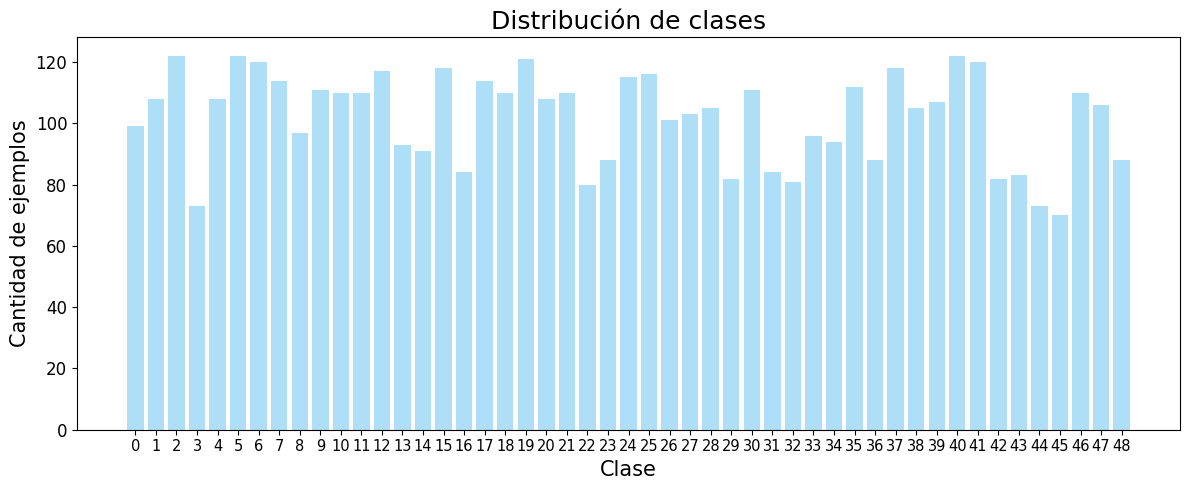

In [8]:
from src.plot import plot_class_distribution
plot_class_distribution(y_images, name_map=name_map, figsize=(12, 5), color='#AEDFF7')

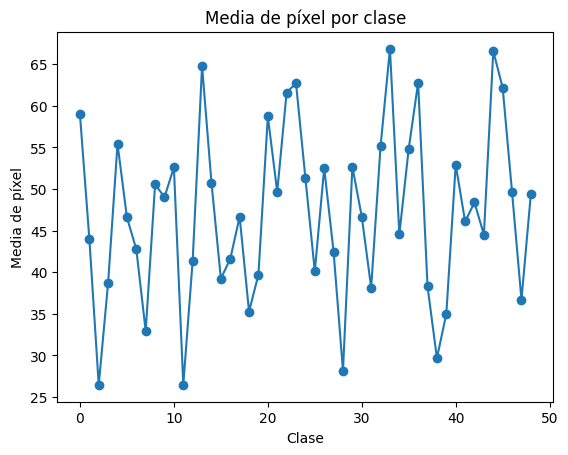

In [9]:
# Media de píxel por clase
medias = [X_images[y_images == cl].mean() for cl in clases]
# Convertir a NumPy para plotting
medias_cp = cp.asnumpy(cp.stack(medias))
clases_cp = cp.asnumpy(clases)
plt.plot(clases_cp, medias_cp, marker='o')
plt.xlabel("Clase")
plt.ylabel("Media de píxel")
plt.title("Media de píxel por clase")
plt.show()

In [10]:
print("Media de píxeles en todo X:", X_images.mean())
print("Desviación estándar de píxeles:", X_images.std())

Media de píxeles en todo X: 46.525505
Desviación estándar de píxeles: 87.5637


#### División del dataset


In [11]:
from src.data_splitting import split_data

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)
X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)




#### Normalización

In [ ]:
# Normalización y conversión de tipo
X_train = X_train.astype(cp.float32) / 255.0
X_val   = X_val.astype(cp.float32)   / 255.0
X_test  = X_test.astype(cp.float32)  / 255.0
X_dev   = X_dev.astype(cp.float32)   / 255.0

# Guardar procesados
out_dir = "data/processed"
os.makedirs(out_dir, exist_ok=True)
cp.savez_compressed(os.path.join(out_dir, "train.npz"), X=X_train, y=y_train)
cp.savez_compressed(os.path.join(out_dir, "val.npz"),   X=X_val,   y=y_val)
cp.savez_compressed(os.path.join(out_dir, "test.npz"),  X=X_test,  y=y_test)


### `2.` **Implementación y Entrenamiento de una Red Neuronal Básica**

red neuronal con 2 capas ocultas, con 100 y 80 nodos

In [13]:
from src.Neural_Network import NeuralNetwork

In [ ]:
# Configuración y entrenamiento de la red
input_size    = X_train.shape[1]
hidden1, hidden2 = 100, 80
n_classes     = int(cp.max(y_train)) + 1
epochs        = 1000

# One-hot encoding
Y_train_oh = cp.eye(n_classes, dtype=cp.float32)[y_train]
Y_val_oh   = cp.eye(n_classes, dtype=cp.float32)[y_val]

M0 = NeuralNetwork(
    layer_sizes=[input_size, hidden1, hidden2, n_classes],
    learning_rate=0.1,
    seed=SEED
)

train_losses, val_losses = M0.train_bp(
    X_train, Y_train_oh,
    X_val= X_val, Y_val=Y_val_oh,
    epochs=epochs,
    plot=True
)

In [ ]:

from src.metrics import Metrics  # importa la clase que guardaste en metrics.py

# Predicciones y métricas
Y_hat_train = M0.forward(X_train)
y_proba_train = Y_hat_train.T
y_pred_train  = cp.argmax(Y_hat_train, axis=0)

Y_hat_val   = M0.forward(X_val)
y_proba_val = Y_hat_val.T
y_pred_val  = cp.argmax(Y_hat_val, axis=0)

met_train = Metrics(y_true=y_train, y_pred=y_pred_train, y_proba=y_proba_train)
met_train.report_metrics(title="Métricas en Conjunto de Entrenamiento", show_matrix_table=False)

met_val = Metrics(y_true=y_val, y_pred=y_pred_val, y_proba=y_proba_val)
met_val.report_metrics(title="Métricas en Conjunto de Validación")



### `3.` **Implementación y Entrenamiento de una Red Neuronal Avanzada**

In [ ]:
epochs = 300

# Comparativa de optimizadores y parámetros
configs = {
    'Batch GD':                 {'optimizer':'gd'},
    'Rate Scheduling Lineal':   {'lr_schedule':'linear', 'learning_rate':0.2},
    'Rate Scheduling Exp':      {'lr_schedule':'exp',    'learning_rate':0.5},
    'Mini-batch Stochastic GD': {'optimizer':'mb',       'batch_size':32,    'learning_rate':0.01},
    'Adam':                     {'optimizer':'adam',     'learning_rate':0.01},
    'L2 (λ=1e-1)':              {'l2_lambda':1e-1},
    'EarlyStop (p=5)':          {'early_stopping':True,  'patience':5},
    'Dropout (p=0.2)':          {'dropout_p':0.2},
    'BatchNorm':                {'use_batchnorm':True,   'learning_rate':0.02},
}

results = []
all_train_losses = {}
all_val_losses   = {}

for name, params in configs.items():
    # --- Instanciar ---
    nn = NeuralNetwork(
        layer_sizes=[input_size, hidden1, hidden2, n_classes],
        learning_rate=params.get('learning_rate', 0.1),
        seed=SEED,
        optimizer=params.get('optimizer', 'gd'),
        batch_size=params.get('batch_size', None),
        l2_lambda=params.get('l2_lambda', 0.0),
        dropout_p=params.get('dropout_p', 0.0),
        use_batchnorm=params.get('use_batchnorm', False),
        early_stopping=params.get('early_stopping', False),
        patience=params.get('patience', 5),
        lr_min = 0.001
    )

    # --- Scheduler ---

    lr_schedule = None
    if params.get('lr_schedule') == 'linear':
        lr_schedule = nn.get_linear_schedule(final_lr=0.01, max_epochs=epochs)
    elif params.get('lr_schedule') == 'exp':
        lr_schedule = nn.get_exponential_schedule(decay_rate=0.01, final_lr=0.001)


    # --- Entrenamiento y captura de pérdidas ---
    train_losses, val_losses = nn.train_bp(
        X_train, Y_train_oh,
        X_val=X_val, Y_val=Y_val_oh,
        epochs=epochs,
        plot=False,
        lr_schedule=lr_schedule
    )
    all_train_losses[name] = train_losses
    all_val_losses[name]   = val_losses

    # --- Métricas en entrenamiento ---
    Yhat_tr   = nn.forward(X_train, train=False)
    ypred_tr  = cp.argmax(Yhat_tr, axis=0)
    yproba_tr = Yhat_tr.T
    m_tr      = Metrics(y_true=y_train, y_pred=ypred_tr, y_proba=yproba_tr)
    acc_tr    = m_tr.accuracy()
    ce_tr     = m_tr.cross_entropy()

    # --- Métricas en validación ---
    Yhat_v   = nn.forward(X_val, train=False)
    ypred_v  = cp.argmax(Yhat_v, axis=0)
    yproba_v = Yhat_v.T
    m_v      = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
    acc_v    = m_v.accuracy()
    ce_v     = m_v.cross_entropy()

    results.append((name, acc_tr, ce_tr, acc_v, ce_v))

# --- Tabla comparativa ---
header = "|Método|Acc Train|CE Train|Acc Val|CE Val|\n"
sep    = "|" + "---|"*5 + "\n"
rows   = "".join(f"|{n}|{at:.4f}|{ct:.4f}|{av:.4f}|{cv:.4f}|\n"
                 for n, at, ct, av, cv in results)

display(Markdown("## Comparativa de Métricas"))
display(Markdown(header + sep + rows))


Epochs: 100%|██████████| 300/300 [00:09<00:00, 31.33it/s]


## Comparativa de Métricas

|Método|Acc Train|CE Train|Acc Val|CE Val|
|---|---|---|---|---|
|Batch GD|0.7700|0.9751|0.5887|1.6482|
|Rate Scheduling Lineal|0.7678|0.9664|0.5975|1.6362|
|Rate Scheduling Exp|0.8588|0.6464|0.6275|1.5579|
|Mini-batch Stochastic GD|1.0000|0.0136|0.6188|2.3518|
|Adam|1.0000|0.0005|0.6288|3.3302|
|L2 (λ=1e-3)|0.7700|0.9751|0.5887|1.6482|
|EarlyStop (p=5)|0.7700|0.9751|0.5887|1.6482|
|Dropout (p=0.2)|0.6869|1.4094|0.5550|1.8145|
|BatchNorm|0.7600|0.9241|0.3900|2.9454|


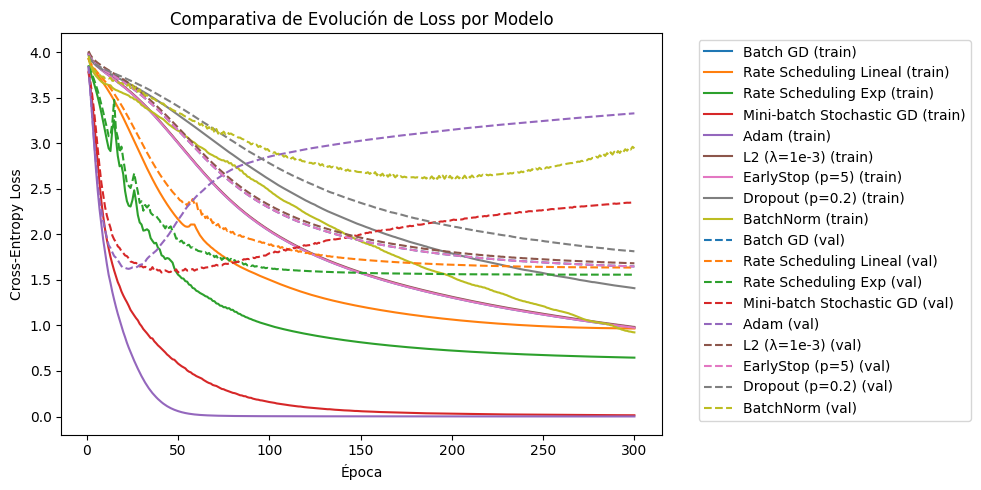

In [25]:
# --- Gráfico conjunto de las losses ---
plt.figure(figsize=(10,5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for i, (name, losses) in enumerate(all_train_losses.items()):
    plt.plot(range(1, len(losses)+1), losses, label=f"{name} (train)", color=colors[i])

for i, (name, losses) in enumerate(all_val_losses.items()):
    plt.plot(range(1, len(losses)+1), losses, '--', label=f"{name} (val)", color=colors[i])

plt.xlabel("Época")
plt.ylabel("Cross-Entropy Loss")
plt.title("Comparativa de Evolución de Loss por Modelo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

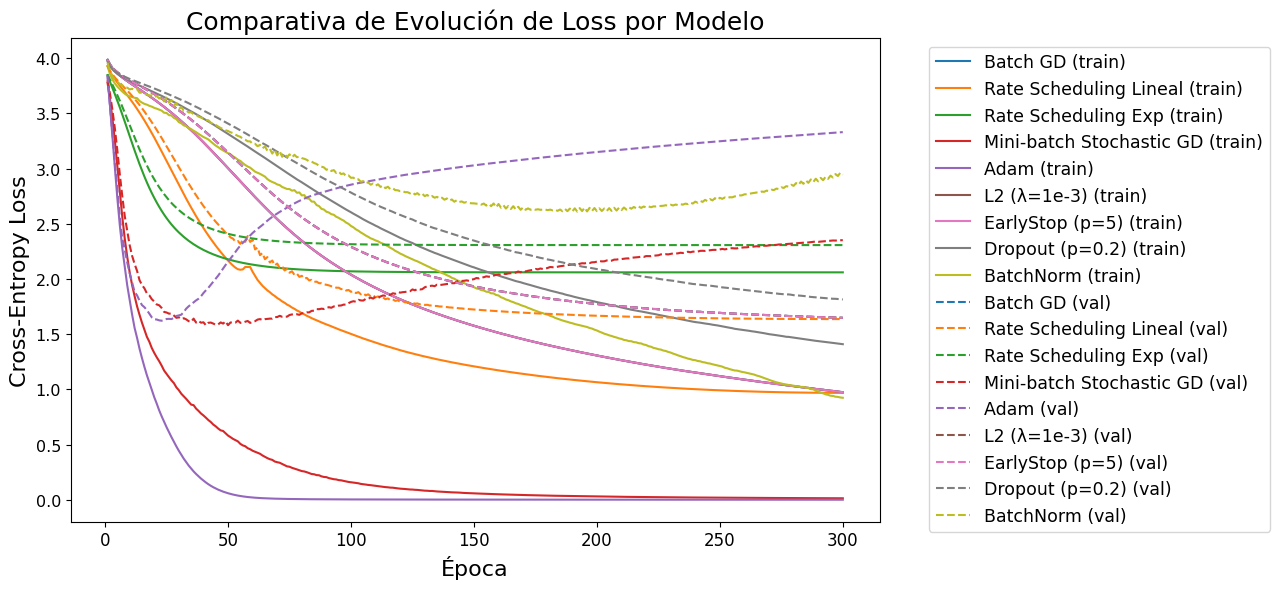

In [35]:
# --- Gráfico conjunto de las losses ---
plt.figure(figsize=(13,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for i, (name, losses) in enumerate(all_train_losses.items()):
    plt.plot(range(1, len(losses)+1), losses, label=f"{name} (train)", color=colors[i])

for i, (name, losses) in enumerate(all_val_losses.items()):
    plt.plot(range(1, len(losses)+1), losses, '--', label=f"{name} (val)", color=colors[i])

plt.xlabel("Época", fontsize=16)
plt.ylabel("Cross-Entropy Loss", fontsize=16)
plt.title("Comparativa de Evolución de Loss por Modelo", fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=11.5)
plt.tight_layout()
plt.show()

prueba de modelos

In [ ]:
# Definición de arquitecturas
architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
]

# Hiperparámetros base
hyperparams = {
    'optimizer':      ['gd', 'mb', 'adam'],
    'learning_rate':  [0.001, 0.01, 0.05, 0.1, 0.2],
    'batch_size':     [None, 1, 16, 32, 64, 128, 256],   # None → full‐batch si optimizer!='mb', 
                                                # 1 → puro SGD, >1 → mini‐batch
    'l2_lambda':      [0.0, 1e-3, 1e-2, 1e-1],
    'dropout_p':      [0.0, 0.15, 0.2, 0.25],
    'use_batchnorm':  [False, True],
    'early_stopping': [False, True],
    'patience':       [5, 10, 20, 50],
    'lr_schedule':    ['none', 'linear', 'exp'],
}

def get_schedule(nn, name, epochs):
    if name == 'linear':
        return nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
    if name == 'exp':
        return nn.get_exponential_schedule(decay_rate=0.05)
    return None

results = []
epochs = 200

for arch in architectures:
    for (opt, lr, bs, l2, dp, bn, es, pat, sched) in itertools.product(
        hyperparams['optimizer'],
        hyperparams['learning_rate'],
        hyperparams['batch_size'],
        hyperparams['l2_lambda'],
        hyperparams['dropout_p'],
        hyperparams['use_batchnorm'],
        hyperparams['early_stopping'],
        hyperparams['patience'],
        hyperparams['lr_schedule'],
    ):
        # Permitir full‑batch solo para 'gd' o 'adam'
        if opt in ['gd', 'adam'] and bs is not None:
            continue
        # Mini‑batch/SGD solo si optimizer='mb'
        if opt == 'mb' and bs is None:
            # bs=None → se interpreta como 1 (SGD puro), podrías forzar bs=1 aquí
            pass

        # Crear y configurar la red
        nn = NeuralNetwork(
            layer_sizes=arch,
            learning_rate=lr,
            seed=SEED,
            optimizer=opt,
            batch_size=bs,
            l2_lambda=l2,
            dropout_p=dp,
            use_batchnorm=bn,
            early_stopping=es,
            patience=pat,
        )

        # Scheduler si aplica
        lr_fn = None
        if sched == 'linear':
            lr_fn = nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
        elif sched == 'exp':
            lr_fn = nn.get_exponential_schedule(decay_rate=0.05)

        # Entrenamos siempre con MB‑SGD, Batch‑GD o Adam según optimizer y batch_size
        nn.train_bp(
            X_train, Y_train_oh,
            X_val=X_val, Y_val=Y_val_oh,
            epochs=epochs,
            plot=False,
            lr_schedule=lr_fn
        )

        # Evaluación en entrenamiento
        Yhat_tr   = nn.forward(X_train, train=False)
        ypred_tr  = cp.argmax(Yhat_tr, axis=0)
        yproba_tr = Yhat_tr.T
        m_tr      = Metrics(y_true=y_train, y_pred=ypred_tr, y_proba=yproba_tr)
        acc_tr, ce_tr = m_tr.accuracy(), m_tr.cross_entropy()

        # Evaluación en validación
        Yhat_v    = nn.forward(X_val, train=False)
        ypred_v   = cp.argmax(Yhat_v, axis=0)
        yproba_v  = Yhat_v.T
        m_v       = Metrics(y_true=y_val,   y_pred=ypred_v, y_proba=yproba_v)
        acc_v, ce_v  = m_v.accuracy(), m_v.cross_entropy()

        results.append((str(arch), opt, bs, acc_tr, ce_tr, acc_v, ce_v))

# Montar y mostrar tabla resultante
header = "|Arch|Opt|BS|Acc Train|CE Train|Acc Val|CE Val|\n"
sep    = "|" + "---|"*7 + "\n"
rows   = "".join(f"|{a}|{o}|{bs}|{tr:.4f}|{ct:.4f}|{val:.4f}|{cv:.4f}|\n"
                 for a, o, bs, tr, ct, val, cv in results)

display(Markdown("## Grid‑Search con Mini‑batch SGD Unificado"))
display(Markdown(header + sep + rows))

Epochs:  14%|█▍        | 29/200 [00:00<00:02, 66.83it/s]